# 07 · 국민연금 LDI 케이스 — 모의 IC 제1호의 숫자 재현

[![Colab에서 열기](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/keerhee/pension-fund-strategy-and-performance/blob/main/W06_LDI%EC%99%80GBI/W06_M7_%EC%8B%A4%EC%8A%B5_Colab/07_%EA%B5%AD%EB%AF%BC%EC%97%B0%EA%B8%88_LDI_%EC%BC%80%EC%9D%B4%EC%8A%A4.ipynb)

**W06 M7 LDI 강의본 9 · 20 · 36 · 53 · 71~74장**(모의 IC)과 케이스 덱의 판정 숫자를 **케이스 데이터(교육용 추계)** 로 재현합니다.
계산 방식은 `W06_M7_케이스데이터/w6m7_compute.py`와 같고, 기대 결과는 `compute_log.txt` · 실습 덱 11장입니다. CSV 숫자는 노트북 안 상수로 옮겼습니다.

| 단계 | 강의 | 이 노트북에서 |
|---|---|---|
| 조건 ① 갭의 실재 | 9 · 20 · 36 · 73장 | 순부채 1,542 / 2,122조 · FR 95 / 69% · D_L 35.0년 · DV01 7.43조/bp · 원화 자산 D 0.85년 · 갭 −34.1년 · 헤지 2.1% → 3.0% · −100bp FR 69 → 49% |
| 수단 | 73장 · 케이스 | 30년 국고채 D 16.1 · IRS 30년 D 16.4 |
| 조건 ② 시장 수용 | 73장 | 장기물 87.3조 × 5년 × 30% = 131조 · IRS 5,986조 × 5% = 299조 |
| 조건 ③ 버퍼 | 53 · 73장 | 사흘 +200bp 증거금 401조 vs 유동자산 123조 · 250bp 버퍼 501조 |
| 조건 ④ 허들 · ⑤ 지침 | 73장 | μ ≥ 5.5% · 국내채권 ≤ 21.8 + 7.0%p · 파생 조항 없음 |
| 안 A · B · C | 9 · 72 · 74장 | 헤지 3 · 5(4.9) · 30% · 갭 · 필요 매입액 · 명목 · 판정 표 → 기본 답 안 B |

**모든 숫자는 '케이스 데이터(교육용 추계) 기준, 우리 계산'** 입니다. 공시 지표는 적립배율이며 적립비율이 아닙니다.

### 0. 준비 — 이 셀부터 실행
한글 폰트(Colab은 나눔고딕 설치, 맥은 Pretendard), 강의 색(잉크 · 라임 · 티일 · 빨강), 강의본 숫자 확인 함수 `check()`를 준비합니다.
`check(이름, 계산값, 강의값, 허용오차)`는 계산이 강의본 숫자와 허용오차 안에서 맞는지 확인하고, 틀리면 멈춥니다(`assert`).
가정을 바꿔 실험할 때는 `FAST = True`로 두면 확인이 멈추지 않고 ✗로 표시만 합니다(M7 세트는 계산이 가벼워 속도 차이는 없음).

In [1]:
# ── 환경 준비: 한글 폰트 · 강의 색 · 확인 함수 (이 셀을 먼저 실행) ──
import sys, os, glob, math, time, subprocess
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager as fm

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul")   # 맥 numpy(Accelerate)의 거짓 경고 — 결과와 무관
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB and not glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"):
    # Colab: 나눔 폰트 설치 (= !apt-get -qq install -y fonts-nanum) — 처음 한 번 10초 안팎
    subprocess.run("apt-get -qq install -y fonts-nanum > /dev/null", shell=True)

def setup_korean_font():
    """로컬 맥은 Pretendard, Colab은 나눔고딕을 matplotlib에 등록한다(폰트 캐시 갱신과 같은 효과)."""
    files = (glob.glob(os.path.expanduser("~/Library/Fonts/Pretendard-*.otf"))
             + glob.glob("/Library/Fonts/Pretendard-*.otf")
             + glob.glob("/usr/share/fonts/truetype/nanum/NanumGothic*.ttf"))
    for f in files:
        try:
            fm.fontManager.addfont(f)
        except Exception:
            pass
    names = {f.name for f in fm.fontManager.ttflist}
    for fam in ["Pretendard", "NanumGothic", "AppleGothic", "Malgun Gothic", "Noto Sans CJK KR"]:
        if fam in names:
            plt.rcParams["font.family"] = fam
            return fam
    return "(한글 폰트 없음 — 그래프 글자가 네모로 보이면 이 셀을 다시 실행)"

FONT = setup_korean_font()
plt.rcParams["axes.unicode_minus"] = False

# 강의 색 — 잉크 · 라임 · 티일 · 빨강 (+ 보조 회색 · 아이보리 바탕)
INK, LIME, TEAL, RED = "#071A1D", "#B7F34A", "#0B6B68", "#C00000"
GRAY, IVORY, OLIVE = "#8A9496", "#F7F5F0", "#5E8C1A"
plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 110,
    "figure.facecolor": "white", "axes.facecolor": IVORY,
    "axes.edgecolor": INK, "axes.labelcolor": INK, "xtick.color": INK, "ytick.color": INK,
    "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlelocation": "left",
    "axes.grid": True, "grid.color": "#DDD8CC", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "axes.axisbelow": True,
    "axes.prop_cycle": matplotlib.cycler(color=[TEAL, INK, RED, OLIVE, GRAY]),
})

# 빠른 모드 — M7 세트는 계산이 가벼워 FAST가 결과를 바꾸지 않는다. True면 확인(check)이 멈추지 않고 표시만 한다(숫자를 바꿔 실험할 때)
FAST = False

CHECKS = []
def check(label, value, lecture, tol, fmt=".4f", unit=""):
    """계산값을 강의본 숫자와 비교한다. 기본(재현) 모드에서는 허용오차를 넘으면 멈춘다(assert)."""
    ok = abs(value - lecture) <= tol + 1e-9      # 허용오차는 보통 강의 표기 자릿수의 반(반올림하면 같은 값)
    CHECKS.append((label, ok))
    print(f"{'✓' if ok else '✗'} {label}: 계산 {value:{fmt}}{unit} · 강의 {lecture:{fmt}}{unit} (허용 ±{tol:g})")
    if not FAST:
        assert ok, f"{label}: 계산 {value} · 강의 {lecture}"

print(f"Colab: {IN_COLAB} · 그래프 폰트: {FONT} · numpy {np.__version__} · matplotlib {matplotlib.__version__}")

Colab: False · 그래프 폰트: Pretendard · numpy 2.0.2 · matplotlib 3.9.4


## 1. 케이스 데이터 — 노트북 안 상수
출처: `W06_M7_케이스데이터/` `fml_w6m7_cashflow.csv`(교육용 추계, W07과 같은 가정) · `fml_w6m7_curve.csv`(3 · 10 · 30 · 50년 공시 + 보간) ·
`fml_w6m7_assets.csv`(금액 · 비중 공시, 듀레이션 · μ는 교육용 가정) · `fml_w6m7_market.csv` · `fml_w6m7_params.csv`. 기준일 2026-09-21.

In [2]:
YEARS = np.arange(2026, 2096)                       # 2026~2095
CONTRIB = np.array([
    70, 75.29, 80.77, 86.46, 92.36, 98.47, 104.8, 111.37, 113.79, 116.27,
    118.8, 121.38, 124.02, 126.72, 129.48, 132.3, 135.18, 138.12, 141.12, 144.19,
    147.33, 150.54, 153.81, 157.16, 160.58, 164.07, 167.64, 171.29, 175.02, 178.83,
    182.72, 186.7, 190.76, 194.91, 199.15, 203.48, 207.91, 212.44, 217.06, 221.78,
    226.61, 231.54, 236.58, 241.72, 246.98, 252.36, 257.85, 263.46, 269.19, 275.05,
    281.04, 287.15, 293.4, 299.78, 306.31, 312.97, 319.78, 326.74, 333.85, 341.12,
    348.54, 356.12, 363.87, 371.79, 379.88, 388.15, 396.59, 405.22, 414.04, 423.05,
])                              # 보험료(조)
BENEFIT = np.array([
    56, 60.2, 64.71, 69.57, 74.79, 80.4, 86.42, 92.91, 99.87, 107.37,
    115.42, 124.07, 133.38, 143.38, 154.14, 165.7, 178.12, 191.48, 205.85, 221.28,
    237.88, 255.72, 274.9, 295.52, 317.68, 339.12, 362.02, 386.45, 412.54, 440.38,
    470.11, 501.84, 535.72, 571.88, 610.48, 651.69, 695.67, 742.63, 792.76, 846.27,
    903.39, 964.37, 1029.47, 1098.96, 1173.14, 1214.2, 1256.69, 1300.68, 1346.2, 1393.32,
    1442.09, 1492.56, 1544.8, 1598.87, 1654.83, 1712.74, 1772.69, 1834.74, 1898.95, 1965.41,
    2034.2, 2105.4, 2179.09, 2255.36, 2334.3, 2416, 2500.56, 2588.08, 2678.66, 2772.41,
])                              # 급여(조)
NET = np.array([
    -14, -15.09, -16.06, -16.89, -17.57, -18.07, -18.38, -18.46, -13.92, -8.9,
    -3.38, 2.69, 9.36, 16.66, 24.66, 33.4, 42.95, 53.37, 64.72, 77.09,
    90.55, 105.18, 121.09, 138.36, 157.1, 175.05, 194.37, 215.16, 237.52, 261.55,
    287.39, 315.15, 344.96, 376.97, 411.33, 448.2, 487.76, 530.2, 575.7, 624.49,
    676.79, 732.84, 792.89, 857.23, 926.15, 961.84, 998.84, 1037.22, 1077.01, 1118.27,
    1161.05, 1205.41, 1251.4, 1299.08, 1348.52, 1399.77, 1452.91, 1507.99, 1565.1, 1624.3,
    1685.66, 1749.28, 1815.22, 1883.57, 1954.41, 2027.85, 2103.96, 2182.85, 2264.62, 2349.36,
])                                  # 순유출 = 급여 − 보험료(조)
MATS = np.array([1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 30.0, 50.0]); YLDS = np.array([3.95, 4.0, 4.06, 4.25, 4.47, 4.58, 4.6, 4.55])    # 국고채 곡선(만기 · %)
ASSETS = {
    "eq_dom": dict(name="국내주식", amount=543.2, target=20.8, D=0.0, krw=0.0, mu=8.0, gov=0.0),
    "eq_for": dict(name="해외주식", amount=661.1, target=35.6, D=0.0, krw=0.0, mu=8.0, gov=0.0),
    "bond_dom": dict(name="국내채권", amount=287.8, target=21.8, D=5.5, krw=1.0, mu=4.2, gov=118.6),
    "bond_for": dict(name="해외채권", amount=110.2, target=7.4, D=6.5, krw=0.0, mu=4.5, gov=0.0),
    "alt": dict(name="대체투자", amount=260.9, target=14.3, D=0.0, krw=0.0, mu=8.0, gov=0.0),
    "cash": dict(name="단기자금", amount=4.6, target=None, D=0.2, krw=1.0, mu=3.75, gov=0.0),
}
P = dict(fund_2025=1458.0, fund_2026h1=1865.6, hurdle=5.5, end=2071,
         dfr_material=-5.0, target_bd=21.8, range_bd=7.0,
         kofr=3.75, swap_spread=-0.15, tenor=30, program_years=5.0,
         cap_issue=0.3, cap_irs=0.05, buffer_bp=250.0, shock_3d=200.0,
         hedge_C=0.3, official_dep45=2064, official_dep55=2071)
MKT = dict(long_issue=87.3, irs_turnover=5986.0, ktb_out=1159.4,
           out30=392.3, out50=45.0)
A_TOT = sum(a["amount"] for a in ASSETS.values())
F0 = P["fund_2025"]
win = YEARS <= P["end"]
print(f"자산 합계 {A_TOT:,.1f}조(2026.6) · 2025년 말 적립금 {F0:,.0f}조 · 부채 창 2026~{P['end']} ({win.sum()}년)")

자산 합계 1,867.8조(2026.6) · 2025년 말 적립금 1,458조 · 부채 창 2026~2071 (46년)


## 2. 조건 ① 갭의 실재 — 순부채 두 눈금 · 듀레이션 · DV01
순부채 = 2026~2071 순유출의 현재가치(2025년 말 기준, 연말 현금흐름). 부채의 수정 듀레이션은 곡선을 ±10bp 평행 이동해 수치로 잽니다.

In [3]:
def z(t, shift_bp=0.0):
    return np.interp(t, MATS, YLDS) + shift_bp / 100

def pv_flows(flows, years, rate=None, shift_bp=0.0):
    t = np.asarray(years) - 2025
    r = np.full(t.shape, rate, dtype=float) if rate is not None else z(t, shift_bp)
    return float(np.sum(flows / (1 + r / 100) ** t))

net, yrs = NET[win], YEARS[win]
L_h = pv_flows(net, yrs, rate=P["hurdle"])
L_g = pv_flows(net, yrs)
PVben, PVcon = pv_flows(BENEFIT[win], yrs), pv_flows(CONTRIB[win], yrs)
D_L = -(pv_flows(net, yrs, shift_bp=10) - pv_flows(net, yrs, shift_bp=-10)) / (2 * L_g * 0.001)
DV01_L = D_L * L_g * 1e-4
FR_h, FR_g = F0 / L_h, F0 / L_g
print(f"순부채 — 자체 5.5%: {L_h:,.0f}조 · 국채 곡선: {L_g:,.0f}조 (급여 PV {PVben:,.0f} − 보험료 PV {PVcon:,.0f})")
print(f"FR_h = {FR_h:.0%} · FR_g = {FR_g:.0%} · (참고: 2026.6 자산 1,865.6조면 FR_g {P['fund_2026h1'] / L_g:.0%})")
print(f"부채 수정 듀레이션 D_L = {D_L:.1f}년 · DV01_L = {DV01_L:.2f}조/bp")
check("순부채 자체 5.5% (조)", L_h, 1542, 0.5, ",.0f")
check("순부채 국채 곡선 (조)", L_g, 2122, 0.5, ",.0f")
check("급여 PV (조)", PVben, 4659, 0.5, ",.0f")
check("보험료 PV (조)", PVcon, 2537, 0.5, ",.0f")
check("FR_h (%)", 100 * FR_h, 95, 0.5, ".1f")
check("FR_g (%)", 100 * FR_g, 69, 0.5, ".1f")
check("D_L (년)", D_L, 35.0, 0.05, ".2f")
check("DV01_L (조/bp)", DV01_L, 7.43, 0.005, ".3f")

순부채 — 자체 5.5%: 1,542조 · 국채 곡선: 2,122조 (급여 PV 4,659 − 보험료 PV 2,537)
FR_h = 95% · FR_g = 69% · (참고: 2026.6 자산 1,865.6조면 FR_g 88%)
부채 수정 듀레이션 D_L = 35.0년 · DV01_L = 7.43조/bp
✓ 순부채 자체 5.5% (조): 계산 1,542 · 강의 1,542 (허용 ±0.5)
✓ 순부채 국채 곡선 (조): 계산 2,122 · 강의 2,122 (허용 ±0.5)
✓ 급여 PV (조): 계산 4,659 · 강의 4,659 (허용 ±0.5)
✓ 보험료 PV (조): 계산 2,537 · 강의 2,537 (허용 ±0.5)
✓ FR_h (%): 계산 94.6 · 강의 95.0 (허용 ±0.5)
✓ FR_g (%): 계산 68.7 · 강의 69.0 (허용 ±0.5)
✓ D_L (년): 계산 34.99 · 강의 35.00 (허용 ±0.05)
✓ DV01_L (조/bp): 계산 7.427 · 강의 7.430 (허용 ±0.005)


**자산 쪽 원화 금리 민감도.** 해외채권 110조는 외화 금리 노출이라 원화 부채의 헤지가 아닙니다 — 국내채권 287.8조 × D 5.5(+ 단기자금)만 셉니다.
헤지비율 h = 자산 DV01 ÷ 부채 DV01(03 노트북의 식).

In [4]:
DV01_A = sum(a["amount"] * a["D"] * a["krw"] * 1e-4 for a in ASSETS.values())
D_A_krw = DV01_A / (A_TOT * 1e-4)
D_A_all = sum(a["amount"] * a["D"] for a in ASSETS.values()) / A_TOT
h0 = DV01_A / DV01_L
gap0 = D_A_krw - D_L
def fr_after(dv01_extra, shift_bp):
    """평행 이동 뒤 국채 기준 FR — 자산은 DV01로(2026.6 DV01을 2025 말 규모로 환산), 부채는 곡선 재할인"""
    A1 = F0 - (DV01_A + dv01_extra) * shift_bp * (F0 / A_TOT)
    return A1 / pv_flows(net, yrs, shift_bp=shift_bp)
L_dn = pv_flows(net, yrs, shift_bp=-100)
dFR_A = 100 * (fr_after(0, -100) - FR_g)
print(f"자산 원화 DV01 {DV01_A:.3f}조/bp → 원화 금리 듀레이션 D_A = {D_A_krw:.2f}년 (외화 채권까지 세면 {D_A_all:.2f}년)")
print(f"듀레이션 갭 = {gap0:.1f}년 · 현 보유 헤지비율 h0 = {h0:.1%}")
print(f"금리 −100bp → 부채 {L_dn:,.0f}조 ({L_dn / L_g - 1:+.0%}) · FR_g {FR_g:.0%} → {fr_after(0, -100):.0%} (ΔFR {dFR_A:+.1f}%p, 임계 {P['dfr_material']:+.0f}%p → {'갭 실재' if dFR_A <= P['dfr_material'] else '갭 비실재'})")
check("자산 원화 DV01 (조/bp)", DV01_A, 0.158, 0.0005, ".4f")
check("원화 자산 D (년)", D_A_krw, 0.85, 0.005, ".3f")
check("외화 채권 포함 D (년)", D_A_all, 1.23, 0.005, ".3f")
check("듀레이션 갭 (년)", gap0, -34.1, 0.05, ".2f")
check("현 보유 헤지비율 (%)", 100 * h0, 2.1, 0.05, ".2f")
check("−100bp 부채 (조)", L_dn, 3019, 0.5, ",.0f")
check("−100bp FR_g (%)", 100 * fr_after(0, -100), 49, 0.5, ".1f")
check("−100bp ΔFR_g (%p)", dFR_A, -20.0, 0.05, ".2f")

자산 원화 DV01 0.158조/bp → 원화 금리 듀레이션 D_A = 0.85년 (외화 채권까지 세면 1.23년)
듀레이션 갭 = -34.1년 · 현 보유 헤지비율 h0 = 2.1%
금리 −100bp → 부채 3,019조 (+42%) · FR_g 69% → 49% (ΔFR -20.0%p, 임계 -5%p → 갭 실재)
✓ 자산 원화 DV01 (조/bp): 계산 0.1584 · 강의 0.1580 (허용 ±0.0005)
✓ 원화 자산 D (년): 계산 0.848 · 강의 0.850 (허용 ±0.005)
✓ 외화 채권 포함 D (년): 계산 1.231 · 강의 1.230 (허용 ±0.005)
✓ 듀레이션 갭 (년): 계산 -34.14 · 강의 -34.10 (허용 ±0.05)
✓ 현 보유 헤지비율 (%): 계산 2.13 · 강의 2.10 (허용 ±0.05)
✓ −100bp 부채 (조): 계산 3,019 · 강의 3,019 (허용 ±0.5)
✓ −100bp FR_g (%): 계산 48.7 · 강의 49.0 (허용 ±0.5)
✓ −100bp ΔFR_g (%p): 계산 -19.99 · 강의 -20.00 (허용 ±0.05)


**소진 연도(강의 22장 각주).** 고정 수익률로 기금 경로를 굴리는 재정추계 방식. 공식 추계는 5.5% → 2071 · 4.5% → 2064이고,
교육용 추계는 5.5% → 2070 · 4.5% → 2065로 1년씩 어긋납니다(현금흐름을 정점 · 소진에 맞춘 근사라서 — 수익률 1%p = 소진 5~7년이라는 메시지는 같음).

In [5]:
def deplete(rate):
    F = F0
    for y, c, b in zip(YEARS, CONTRIB, BENEFIT):
        F = F * (1 + rate / 100) + c - b
        if F <= 0: return int(y)
dep55, dep45 = deplete(5.5), deplete(4.5)
print(f"교육용 추계 소진 — 5.5%: {dep55} · 4.5%: {dep45} (공식 {P['official_dep55']} · {P['official_dep45']}) → 수익률 1%p = 소진 {dep55 - dep45}년")
check("교육용 소진 5.5% (compute_log)", dep55, 2070, 0, ".0f")
check("교육용 소진 4.5% (compute_log)", dep45, 2065, 0, ".0f")

교육용 추계 소진 — 5.5%: 2070 · 4.5%: 2065 (공식 2071 · 2064) → 수익률 1%p = 소진 5년
✓ 교육용 소진 5.5% (compute_log): 계산 2070 · 강의 2070 (허용 ±0)
✓ 교육용 소진 4.5% (compute_log): 계산 2065 · 강의 2065 (허용 ±0)


## 3. 수단 · 시장 수용 · 유동자산 · 허들 (조건 ②~⑤의 입력)
- 30년 국고채(수익률 4.60%) · 30년 IRS(고정 4.45%)의 수정 듀레이션
- 조건 ②: 현물 매입 ≤ 장기물(20 · 30 · 50년) 연 발행 × 5년 × 30% · IRS 명목 ≤ 연간 원화 IRS 거래 × 5%
- 조건 ③: 담보 적격 유동자산 = 단기자금 + 국고채 보유
- 조건 ④: 2027 SAA 목표 구성의 기대수익 μ_SAA(위험자산 8.0 · 국내채권 4.2 · 해외채권 4.5, 교육용)

In [6]:
def par_mod_duration(T, y):
    c = y / 100; t = np.arange(1, T + 1); pv = c / (1 + c) ** t; pv[-1] += 1 / (1 + c) ** T
    return float(np.sum(t * pv) / (1 + c))
y30 = z(P["tenor"])
D_bond30 = par_mod_duration(P["tenor"], y30); D_irs30 = par_mod_duration(P["tenor"], y30 + P["swap_spread"])
dv01_bond, dv01_irs = D_bond30 * 1e-4, D_irs30 * 1e-4          # 1조당 DV01(조/bp)
cap_bond = P["cap_issue"] * P["program_years"] * MKT["long_issue"]
cap_irs = P["cap_irs"] * MKT["irs_turnover"]
liquid = ASSETS["cash"]["amount"] + ASSETS["bond_dom"]["gov"]
long_out = MKT["out30"] + MKT["out50"]
tw = {k: (a["target"] or 0.0) for k, a in ASSETS.items()}; tw["cash"] = max(0.0, 100 - sum(tw.values()))
mu_saa = sum(tw[k] * ASSETS[k]["mu"] for k in ASSETS) / 100
BD_TARGET = P["target_bd"] / 100 * A_TOT
D_BD = ASSETS["bond_dom"]["D"]
def dv01_assets(bond30):
    """SAA 목표 국내채권(D 5.5) 중 bond30조를 30년물로 바꿔 든 경우의 원화 DV01"""
    return (BD_TARGET - bond30) * D_BD * 1e-4 + bond30 * dv01_bond
DV01_SAA = dv01_assets(0.0); h_saa = DV01_SAA / DV01_L
print(f"30년 국고채 D {D_bond30:.1f}년(100조 = {100 * dv01_bond:.3f}조/bp) · IRS 30년 D {D_irs30:.1f}년")
print(f"조건 ② 현물 상한 {MKT['long_issue']}조 × 5년 × 30% = {cap_bond:.0f}조 · IRS 상한 {MKT['irs_turnover']:,.0f}조 × 5% = {cap_irs:.0f}조 · 초장기 잔액 {long_out:.0f}조")
print(f"조건 ③ 유동자산 = {ASSETS['cash']['amount']} + {ASSETS['bond_dom']['gov']} = {liquid:.1f}조 · 조건 ④ μ_SAA = {mu_saa:.2f}% vs 허들 {P['hurdle']}%")
print(f"출발점 — 2027 목표 비중 이행 후 국내채권 {BD_TARGET:.0f}조 × D 5.5 → DV01 {DV01_SAA:.3f}조/bp · 헤지 {h_saa:.1%}")
check("30년 국고채 수정 D (년)", D_bond30, 16.1, 0.05, ".2f")
check("IRS 30년 수정 D (년)", D_irs30, 16.4, 0.05, ".2f")
check("조건 ② 현물 상한 (조)", cap_bond, 131, 0.5, ".1f")
check("조건 ② IRS 상한 (조)", cap_irs, 299, 0.5, ".1f")
check("초장기 국고채 잔액 (조)", long_out, 437, 0.5, ".1f")
check("유동자산 (조)", liquid, 123.2, 0.05, ".2f")
check("μ_SAA (%)", mu_saa, 6.91, 0.005, ".3f")
check("2027 목표 이행 시 헤지 (%)", 100 * h_saa, 3.0, 0.05, ".2f")

30년 국고채 D 16.1년(100조 = 0.161조/bp) · IRS 30년 D 16.4년
조건 ② 현물 상한 87.3조 × 5년 × 30% = 131조 · IRS 상한 5,986조 × 5% = 299조 · 초장기 잔액 437조
조건 ③ 유동자산 = 4.6 + 118.6 = 123.2조 · 조건 ④ μ_SAA = 6.91% vs 허들 5.5%
출발점 — 2027 목표 비중 이행 후 국내채권 407조 × D 5.5 → DV01 0.224조/bp · 헤지 3.0%
✓ 30년 국고채 수정 D (년): 계산 16.10 · 강의 16.10 (허용 ±0.05)
✓ IRS 30년 수정 D (년): 계산 16.39 · 강의 16.40 (허용 ±0.05)
✓ 조건 ② 현물 상한 (조): 계산 130.9 · 강의 131.0 (허용 ±0.5)
✓ 조건 ② IRS 상한 (조): 계산 299.3 · 강의 299.0 (허용 ±0.5)
✓ 초장기 국고채 잔액 (조): 계산 437.3 · 강의 437.0 (허용 ±0.5)
✓ 유동자산 (조): 계산 123.20 · 강의 123.20 (허용 ±0.05)
✓ μ_SAA (%): 계산 6.908 · 강의 6.910 (허용 ±0.005)
✓ 2027 목표 이행 시 헤지 (%): 계산 3.02 · 강의 3.00 (허용 ±0.05)


## 4. 안 A · B · C 판정 (강의 9 · 72 · 74장)
- **안 A · 현행 유지** — LDI 조치 없음, 2027 목표 비중만 채운다(헤지 3%), 부채 벤치마크 없음
- **안 B · 30년 국고채 교체** — 보유 채권 131조(시장 상한)를 5년간 30년 국고채로 바꿔 든다, 부채 벤치마크 공시, 증거금 없음
- **안 C · IRS 오버레이** — 30년 고정금리 수취 스왑을 명목 1,223조 맺어 헤지 30%, 부채 벤치마크 공시

판정: ① 갭이 실재하면 부채 지표(LBP) 없는 안 탈락 · ② 매입 ≤ 131조 · IRS ≤ 299조 · ③ 사흘 +200bp 증거금 · 250bp 버퍼 ≤ 유동자산 ·
④ 헤지 후 μ ≥ 5.5% · ⑤ 국내채권 ≤ 21.8 + 7.0%p, IRS는 지침에 파생 조항이 없어 개정 전 불가.

In [7]:
cond1_gap = dFR_A <= P["dfr_material"]
def mu_after_bond(buy):
    inside = min(buy, BD_TARGET); beyond = max(0.0, buy - BD_TARGET)
    return mu_saa + inside / A_TOT * (y30 - ASSETS["bond_dom"]["mu"]) + beyond / A_TOT * (y30 - 8.0)
def mu_after_irs(notional):
    return mu_saa + notional / A_TOT * ((y30 + P["swap_spread"]) - P["kofr"])

def judge(name, buy=0.0, irs=0.0, lbp=1):
    dv01_tot = dv01_assets(buy) + irs * dv01_irs
    h = dv01_tot / DV01_L
    gap = dv01_tot / (A_TOT * 1e-4) - D_L
    fr_dn = fr_after(dv01_tot - DV01_A, -100)
    vm3 = irs * dv01_irs * P["shock_3d"]; buf = irs * dv01_irs * P["buffer_bp"]
    mu = mu_after_bond(buy) if buy else (mu_after_irs(irs) if irs else mu_saa)
    bd_pct = max(BD_TARGET, buy) / A_TOT * 100
    c = [bool(lbp) if cond1_gap else True,
         buy <= cap_bond + 1e-9 and irs <= cap_irs + 1e-9,
         buf <= liquid and vm3 <= liquid,
         mu >= P["hurdle"],
         bd_pct <= P["target_bd"] + P["range_bd"] + 1e-9 and irs == 0]
    return dict(안=name, 매입=buy, 명목=irs, 헤지=h, 갭=gap, FR_dn=fr_dn, dFR=100 * (fr_dn - FR_g), 증거금=vm3, 버퍼=buf, mu=mu,
                국내채권=bd_pct, 상한대비=(irs / cap_irs if irs else buy / cap_bond), 조건=c)

irs_C = (P["hedge_C"] * DV01_L - DV01_SAA) / dv01_irs
OPTS = [judge("A", lbp=0), judge("B", buy=cap_bond), judge("C", irs=irs_C)]
ok = lambda b: "통과" if b else "탈락"
print(f"{'안':2s} {'30년물':>7s} {'IRS 명목':>9s} {'헤지':>6s} {'갭':>7s} {'−100bp FR':>10s} {'증거금':>7s} {'버퍼':>6s} {'μ':>6s}   조건 ①~⑤")
for o in OPTS:
    print(f"{o['안']:2s} {o['매입']:6.0f}조 {o['명목']:8,.0f}조 {o['헤지']:6.1%} {o['갭']:6.1f}년 {o['FR_dn']:5.0%}({o['dFR']:+.1f}) {o['증거금']:6.0f}조 {o['버퍼']:5.0f}조 {o['mu']:5.2f}%   "
          + " · ".join(ok(x) for x in o["조건"]))
A_, B_, C_ = OPTS
check("안 A 헤지 (%)", 100 * A_["헤지"], 3.0, 0.05, ".2f")
check("안 A 갭 (년)", A_["갭"], -33.8, 0.05, ".2f")
check("안 A −100bp ΔFR (%p)", A_["dFR"], -19.8, 0.05, ".2f")
check("안 B 매입 (조)", B_["매입"], 131, 0.5, ".1f")
check("안 B 헤지 (%)", 100 * B_["헤지"], 4.9, 0.05, ".2f")
check("안 B 갭 (년)", B_["갭"], -33.1, 0.05, ".2f")
check("안 B μ (%)", B_["mu"], 6.94, 0.005, ".3f")
check("안 C IRS 명목 (조)", C_["명목"], 1223, 0.5, ",.1f")
check("안 C 헤지 (%)", 100 * C_["헤지"], 30.0, 0.05, ".2f")
check("안 C 갭 (년)", C_["갭"], -23.1, 0.05, ".2f")
check("안 C −100bp FR (%)", 100 * C_["FR_dn"], 54, 0.5, ".1f")
check("안 C 사흘 +200bp 증거금 (조)", C_["증거금"], 401, 0.5, ".1f")
check("안 C 250bp 버퍼 (조)", C_["버퍼"], 501, 0.5, ".1f")
check("안 C IRS ÷ 시장 상한 (배)", C_["상한대비"], 4.1, 0.05, ".2f")
check("안 C μ (%)", C_["mu"], 7.37, 0.005, ".3f")

안     30년물    IRS 명목     헤지       갭  −100bp FR     증거금     버퍼      μ   조건 ①~⑤
A       0조        0조   3.0%  -33.8년   49%(-19.8)      0조     0조  6.91%   탈락 · 통과 · 통과 · 통과 · 통과
B     131조        0조   4.9%  -33.1년   49%(-19.5)      0조     0조  6.94%   통과 · 통과 · 통과 · 통과 · 통과
C       0조    1,223조  30.0%  -23.1년   54%(-14.6)    401조   501조  7.37%   통과 · 탈락 · 탈락 · 통과 · 탈락
✓ 안 A 헤지 (%): 계산 3.02 · 강의 3.00 (허용 ±0.05)
✓ 안 A 갭 (년): 계산 -33.79 · 강의 -33.80 (허용 ±0.05)
✓ 안 A −100bp ΔFR (%p): 계산 -19.82 · 강의 -19.80 (허용 ±0.05)
✓ 안 B 매입 (조): 계산 130.9 · 강의 131.0 (허용 ±0.5)
✓ 안 B 헤지 (%): 계산 4.88 · 강의 4.90 (허용 ±0.05)
✓ 안 B 갭 (년): 계산 -33.05 · 강의 -33.10 (허용 ±0.05)
✓ 안 B μ (%): 계산 6.936 · 강의 6.940 (허용 ±0.005)
✓ 안 C IRS 명목 (조): 계산 1,223.1 · 강의 1,223.0 (허용 ±0.5)
✓ 안 C 헤지 (%): 계산 30.00 · 강의 30.00 (허용 ±0.05)
✓ 안 C 갭 (년): 계산 -23.06 · 강의 -23.10 (허용 ±0.05)
✓ 안 C −100bp FR (%): 계산 54.1 · 강의 54.0 (허용 ±0.5)
✓ 안 C 사흘 +200bp 증거금 (조): 계산 400.8 · 강의 401.0 (허용 ±0.5)
✓ 안 C 250bp 버퍼 (조): 계산 501.0 · 강의 501.0 (허용 ±0.5)
✓ 안 C IRS ÷ 시장

**판정 조건 ①~⑤ 표.** 안 B만 다섯 조건을 모두 통과합니다 → **기본 답: 안 B 조건부 승인**(부채 벤치마크 도입 + 시장 상한 131조까지 30년 국고채 교체).
헤지 후에도 남는 갭(−33년)의 부담자를 의결문에 반드시 적습니다.

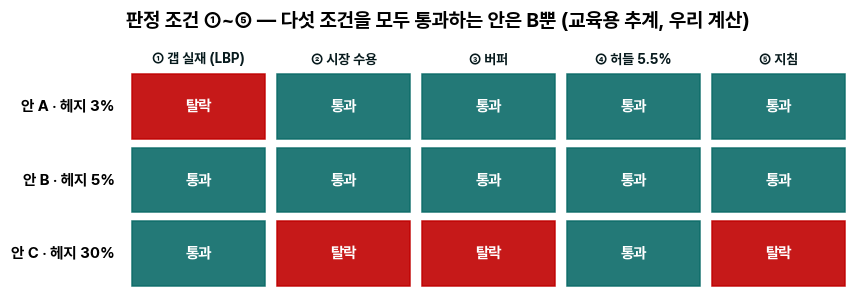

✓ 안 A 판정 (통과 조건 수): 계산 4 · 강의 4 (허용 ±0)
✓ 안 B 판정 (통과 조건 수): 계산 5 · 강의 5 (허용 ±0)
✓ 안 C 판정 (통과 조건 수): 계산 2 · 강의 2 (허용 ±0)


In [8]:
NAMES = ["① 갭 실재 (LBP)", "② 시장 수용", "③ 버퍼", "④ 허들 5.5%", "⑤ 지침"]
fig, ax = plt.subplots(figsize=(8.5, 2.6))
ax.set_xlim(0, 5); ax.set_ylim(0, 3); ax.axis("off")
for j, n in enumerate(NAMES):
    ax.text(j + 0.5, 3.05, n, ha="center", va="bottom", fontsize=9, fontweight="bold", color=INK)
for i, o in enumerate(OPTS):
    yy = 2 - i
    ax.text(-0.08, yy + 0.5, f"안 {o['안']} · 헤지 {o['헤지']:.0%}", ha="right", va="center", fontsize=10, fontweight="bold")
    for j, c in enumerate(o["조건"]):
        ax.add_patch(plt.Rectangle((j + 0.04, yy + 0.06), 0.92, 0.88, color=TEAL if c else RED, alpha=0.9))
        ax.text(j + 0.5, yy + 0.5, "통과" if c else "탈락", ha="center", va="center", color="white", fontweight="bold")
ax.set_title("판정 조건 ①~⑤ — 다섯 조건을 모두 통과하는 안은 B뿐 (교육용 추계, 우리 계산)", pad=28)
plt.show()
for o in OPTS:
    check(f"안 {o['안']} 판정 (통과 조건 수)", sum(o["조건"]), {"A": 4, "B": 5, "C": 2}[o["안"]], 0, ".0f")

## 5. 그래프 — 금리 이동에 따른 적립비율(두 눈금)
국채 눈금(FR_g)은 곡선을 평행 이동해 부채를 다시 할인하고, 자산은 안별 DV01로 움직입니다. 자체 눈금(FR_h)은 할인율이 5.5%로 고정이라
부채가 움직이지 않고 자산 DV01만큼만 흔들립니다 — **두 눈금은 금리 위험을 전혀 다르게 보여 줍니다.**

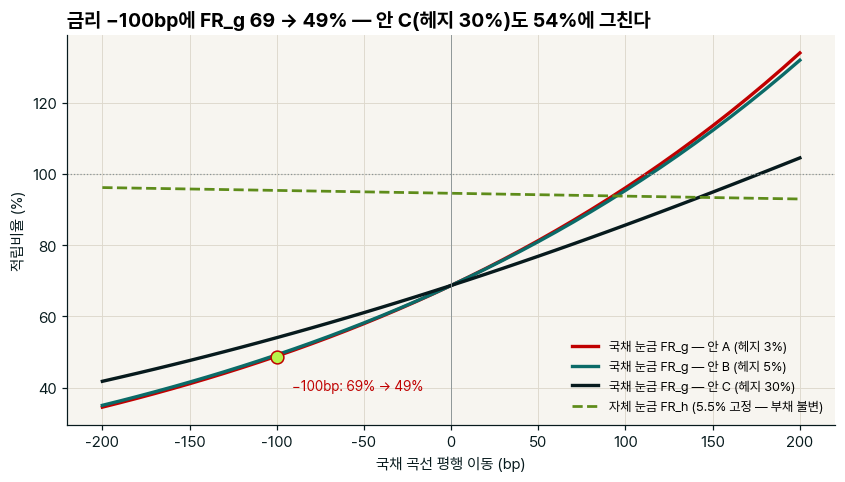

In [9]:
shifts = np.arange(-200, 201, 10)
fig, ax = plt.subplots(figsize=(9, 4.6))
for o, c in zip(OPTS, [RED, TEAL, INK]):
    extra = dv01_assets(o["매입"]) + o["명목"] * dv01_irs - DV01_A
    ax.plot(shifts, [100 * fr_after(extra, s) for s in shifts], color=c, lw=2.2, label=f"국채 눈금 FR_g — 안 {o['안']} (헤지 {o['헤지']:.0%})")
FRh_line = [100 * (F0 - DV01_A * s * (F0 / A_TOT)) / L_h for s in shifts]
ax.plot(shifts, FRh_line, color=OLIVE, lw=1.8, ls="--", label="자체 눈금 FR_h (5.5% 고정 — 부채 불변)")
ax.axhline(100, color=GRAY, lw=0.8, ls=":"); ax.axvline(0, color=GRAY, lw=0.6)
ax.annotate(f"−100bp: {FR_g:.0%} → {fr_after(0, -100):.0%}", (-100, 100 * fr_after(0, -100)), textcoords="offset points", xytext=(10, -22), color=RED, fontsize=9)
ax.scatter([-100], [100 * fr_after(0, -100)], color=LIME, edgecolor=RED, zorder=5, s=70)
ax.set_xlabel("국채 곡선 평행 이동 (bp)"); ax.set_ylabel("적립비율 (%)")
ax.set_title("금리 −100bp에 FR_g 69 → 49% — 안 C(헤지 30%)도 54%에 그친다")
ax.legend(fontsize=8.5, loc="lower right")
plt.show()

## 6. 그래프 — 안별 헤지비율 · 증거금 vs 유동자산 · 시장 상한

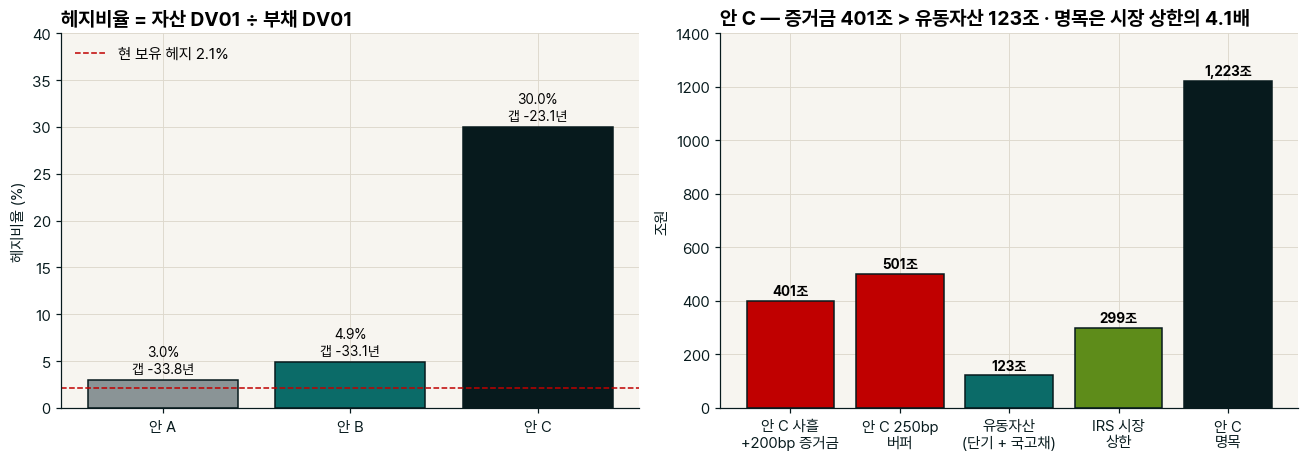

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))
bars = ax1.bar([f"안 {o['안']}" for o in OPTS], [100 * o["헤지"] for o in OPTS], color=[GRAY, TEAL, INK], edgecolor=INK)
for b, o in zip(bars, OPTS):
    ax1.text(b.get_x() + b.get_width() / 2, 100 * o["헤지"] + 0.8, f"{o['헤지']:.1%}\n갭 {o['갭']:.1f}년", ha="center", fontsize=9)
ax1.axhline(100 * h0, color=RED, ls="--", lw=1, label=f"현 보유 헤지 {h0:.1%}"); ax1.legend(loc="upper left")
ax1.set_ylim(0, 40); ax1.set_ylabel("헤지비율 (%)"); ax1.set_title("헤지비율 = 자산 DV01 ÷ 부채 DV01")
labels = ["안 C 사흘\n+200bp 증거금", "안 C 250bp\n버퍼", "유동자산\n(단기 + 국고채)", "IRS 시장\n상한", "안 C\n명목"]
vals = [C_["증거금"], C_["버퍼"], liquid, cap_irs, C_["명목"]]
cols = [RED, RED, TEAL, OLIVE, INK]
bars = ax2.bar(labels, vals, color=cols, edgecolor=INK)
for b, v in zip(bars, vals):
    ax2.text(b.get_x() + b.get_width() / 2, v + 20, f"{v:,.0f}조", ha="center", fontsize=9, fontweight="bold")
ax2.set_ylabel("조원"); ax2.set_ylim(0, 1400)
ax2.set_title("안 C — 증거금 401조 > 유동자산 123조 · 명목은 시장 상한의 4.1배")
fig.tight_layout(); plt.show()

## 7. 헤지 비율 격자 — 현물로 / IRS로 각각 얼마가 드나 (compute_log '격자')
목표 헤지비율 h\*에서 필요한 추가 DV01 = h\*·DV01_L − DV01_SAA. 현물은 D 5.5 채권을 D 16.1로 바꾸는 순증분으로, IRS는 명목 × D 16.4로 채웁니다.

In [11]:
print(f"{'h*':>5s} {'현물 매입':>9s} {'= 장기물 발행':>12s} {'IRS 명목':>9s} {'사흘 증거금':>10s} {'μ 현물':>7s} {'μ IRS':>7s}")
GRID = []
for ht in [0.05, 0.10, 0.20, 0.30, 0.50, 0.70, 1.00]:
    need = max(0.0, ht * DV01_L - DV01_SAA)
    bond = need / (dv01_bond - D_BD * 1e-4); irs = need / dv01_irs
    GRID.append((ht, bond, irs))
    print(f"{ht:5.0%} {bond:8,.0f}조 {bond / MKT['long_issue']:10.1f}년치 {irs:8,.0f}조 {irs * dv01_irs * 200:9,.0f}조 {mu_after_bond(bond):6.2f}% {mu_after_irs(irs):6.2f}%")
check("격자 h 30% IRS 명목 (조)", GRID[3][2], 1223, 0.5, ",.0f")
check("격자 h 100% 현물 매입 (조)", GRID[6][1], 6796, 0.5, ",.0f")
print("→ 현물만으로 헤지 30%를 하려면 장기물 발행 20년치 이상이 필요하다 — 조건 ②가 현물 헤지의 천장을 정한다")

   h*     현물 매입     = 장기물 발행    IRS 명목     사흘 증거금    μ 현물   μ IRS
   5%      139조        1.6년치       90조        29조   6.94%   6.94%
  10%      489조        5.6년치      317조       104조   6.85%   7.03%
  20%    1,190조       13.6년치      770조       252조   5.57%   7.20%
  30%    1,891조       21.7년치    1,223조       401조   4.29%   7.37%
  50%    3,292조       37.7년치    2,130조       698조   1.74%   7.71%
  70%    4,694조       53.8년치    3,036조       995조  -0.81%   8.05%
 100%    6,796조       77.8년치    4,396조     1,441조  -4.63%   8.56%
✓ 격자 h 30% IRS 명목 (조): 계산 1,223 · 강의 1,223 (허용 ±0.5)
✓ 격자 h 100% 현물 매입 (조): 계산 6,796 · 강의 6,796 (허용 ±0.5)
→ 현물만으로 헤지 30%를 하려면 장기물 발행 20년치 이상이 필요하다 — 조건 ②가 현물 헤지의 천장을 정한다


## 8. 정리 — IC 발언으로
- "조건 ①: 국채 눈금 FR 69%, −100bp에 49%(−20%p) — 갭은 실재한다. 부채 벤치마크 없는 안 A는 탈락."
- "조건 ②: 시장이 받아 줄 현물은 131조 — 헤지는 3 → 4.9%까지. 안 C의 스왑 1,223조는 IRS 상한 299조의 4.1배."
- "조건 ③: 안 C는 사흘 +200bp에 증거금 401조, 유동자산은 123조 — 2022 영국의 조건이 그대로 재현된다."
- **기본 답: 안 B 조건부 승인** — 그리고 헤지 후에도 남는 갭 −33년의 부담자를 의결문에 적는다.

---
### 확인 결과 요약
이 노트북에서 강의본 숫자와 비교한 항목을 모아 봅니다. 모두 ✓이면 강의본 숫자를 그대로 재현한 것입니다.

In [12]:
# ── 확인 결과 요약 ──
n_ok = sum(ok for _, ok in CHECKS)
print(f"강의본 숫자 확인 {n_ok} / {len(CHECKS)} 통과" + (" — 빠른 모드라 일부 차이는 정상" if FAST else ""))
for label, ok in CHECKS:
    if not ok:
        print("  ✗", label)

강의본 숫자 확인 46 / 46 통과


---
## 바꿔 보기 (연습 문제)

1. 조건 ②의 임계를 '장기물 발행의 50% × 10년'으로 완화하면 안 B의 매입액 · 헤지비율 · 갭은? (`judge('B2', buy=0.5 * 10 * MKT['long_issue'])`)
2. 안 C를 헤지 10%로 줄이면 IRS 명목 · 사흘 증거금은? 조건 ② · ③을 통과하나? (`irs = (0.10 * DV01_L - DV01_SAA) / dv01_irs`)
3. 국채 곡선이 전체적으로 +100bp 오른 상태에서 출발하면 FR_g와 D_L은 어떻게 바뀌나? (`pv_flows(net, yrs, shift_bp=100)`)

아래 빈 셀에서 직접 해 보세요. 위 셀의 함수를 그대로 불러 쓰면 됩니다.

In [13]:
# 여기에 직접 해 보기

In [14]:
# 여기에 직접 해 보기

In [15]:
# 여기에 직접 해 보기